In [6]:
import pandas as pd

In [7]:
PIB = "Tabela 6612 - sem ajuste sazonal.xlsx"
PIB_ajuste_sazonal = "Tabela 6613 - com ajuste sazonal.xlsx"

In [8]:
DF_PIB_SEM_AJUSTE = pd.read_excel(PIB, sheet_name="Tabela")
DF_PIB_ajuste_sazonal = pd.read_excel(PIB_ajuste_sazonal, sheet_name="Tabela" )

In [12]:
import numpy as np

# --- Correção e Preparação do DataFrame ---

# O DataFrame DF_PIB_ajuste_sazonal foi carregado com a primeira linha como cabeçalho.
# Vamos corrigir isso.

# 1. Obter a primeira linha (que foi lida como cabeçalho)
header_row = pd.DataFrame([DF_PIB_ajuste_sazonal.columns], columns=['data_raw', 'pib'])

# 2. Renomear as colunas do DataFrame principal
DF_PIB_ajuste_sazonal.columns = ['data_raw', 'pib']

# 3. Concatenar a linha do cabeçalho de volta ao topo do DataFrame
pib_df_corrigido = pd.concat([header_row, DF_PIB_ajuste_sazonal], ignore_index=True)


# --- Transformação dos Dados ---

# Função para converter o formato de texto "Xº trimestre de AAAA" para um objeto de data
def parse_ibge_quarter(date_str):
    if not isinstance(date_str, str):
        return pd.NaT
    
    parts = date_str.strip().split(' ')
    quarter_str = parts[0].replace('º', '')
    
    # Lida com possíveis erros de conversão se a string não for um número
    if not quarter_str.isdigit():
        return pd.NaT
        
    quarter = int(quarter_str)
    year = int(parts[-1])
    month = quarter * 3 # Mapeia o trimestre para o mês final
    
    # Retorna uma data de final de trimestre, que é uma boa prática para séries temporais
    return pd.to_datetime(f'{year}-{month}-01') + pd.offsets.QuarterEnd(0)

# 1. Aplicar a função para criar a coluna de data
pib_df_corrigido['data'] = pib_df_corrigido['data_raw'].apply(parse_ibge_quarter)

# 2. Remover linhas onde a conversão de data falhou (se houver) e definir a data como índice
pib_df_corrigido.dropna(subset=['data'], inplace=True)
pib_df_corrigido.set_index('data', inplace=True)

# 3. Garantir que a coluna 'pib' seja numérica
pib_df_corrigido['pib'] = pd.to_numeric(pib_df_corrigido['pib'])


# --- Criação das Variáveis de Análise (Conforme Documentação) ---

# 1. Aplicar o logaritmo natural na série do PIB
pib_df_corrigido['ln_pib'] = np.log(pib_df_corrigido['pib'])

# 2. Calcular a taxa de crescimento do PIB em porcentagem
# A fórmula é: (ln(PIB_t) - ln(PIB_t-1)) * 100
pib_df_corrigido['crescimento_pib'] = pib_df_corrigido['ln_pib'].diff() * 100


# --- Verificação Final ---

# Exibir as 5 primeiras e as 5 últimas linhas do DataFrame final
print("--- DataFrame Final do PIB (Head) ---")
print(pib_df_corrigido.head())
print("\n" + "--- DataFrame Final do PIB (Tail) ---")
print(pib_df_corrigido.tail())

# Verificar informações e tipos de dados
print("\n" + "--- Informações do DataFrame ---")
pib_df_corrigido.info()

--- DataFrame Final do PIB (Head) ---
                     data_raw          pib     ln_pib  crescimento_pib
data                                                                  
1996-03-31  1º trimestre 1996  175461.6360  12.075176              NaN
1996-06-30  2º trimestre 1996  177540.3069  12.086953         1.177724
1996-09-30  3º trimestre 1996  184101.2613  12.123241         3.628828
1996-12-31  4º trimestre 1996  182347.0228  12.113667        -0.957435
1997-03-31  1º trimestre 1997  184308.8135  12.124368         1.070109

--- DataFrame Final do PIB (Tail) ---
                     data_raw          pib     ln_pib  crescimento_pib
data                                                                  
2024-09-30  3º trimestre 2024  337698.0882  12.729908         0.894300
2024-12-31  4º trimestre 2024  337205.2574  12.728447        -0.146045
2025-03-31  1º trimestre 2025  342381.8460  12.743682         1.523481
2025-06-30  2º trimestre 2025  343478.5118  12.746880         0.319793


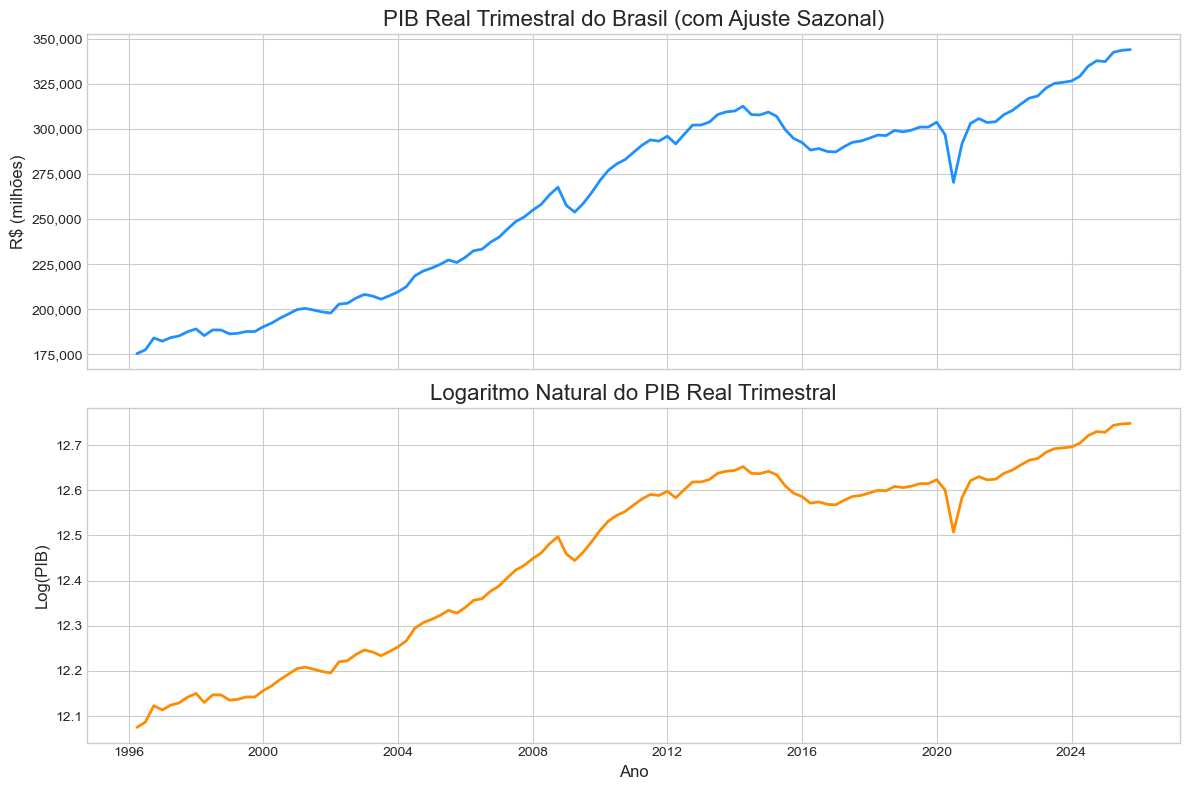

In [14]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# --- Configurações de Estilo do Gráfico (Opcional, para melhor visualização) ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8) # Tamanho da figura
plt.rcParams['axes.titlesize'] = 16 # Tamanho do título
plt.rcParams['axes.labelsize'] = 12 # Tamanho dos rótulos dos eixos


# --- Criação dos Gráficos ---

# Criar uma figura com dois subplots (um em cima do outro)
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

# --- Gráfico 1: PIB em Nível ---
ax1.plot(pib_df_corrigido.index, pib_df_corrigido['pib'], color='dodgerblue', linewidth=2)
ax1.set_title('PIB Real Trimestral do Brasil (com Ajuste Sazonal)')
ax1.set_ylabel('R$ (milhões)')

# Formatar o eixo y para exibir os números por extenso, sem notação científica
formatter = mticker.FuncFormatter(lambda x, p: format(int(x), ','))
ax1.yaxis.set_major_formatter(formatter)


# --- Gráfico 2: Logaritmo do PIB ---
ax2.plot(pib_df_corrigido.index, pib_df_corrigido['ln_pib'], color='darkorange', linewidth=2)
ax2.set_title('Logaritmo Natural do PIB Real Trimestral')
ax2.set_ylabel('Log(PIB)')
ax2.set_xlabel('Ano')


# --- Ajustes Finais ---
plt.tight_layout() # Ajusta o espaçamento para evitar sobreposição
plt.show()


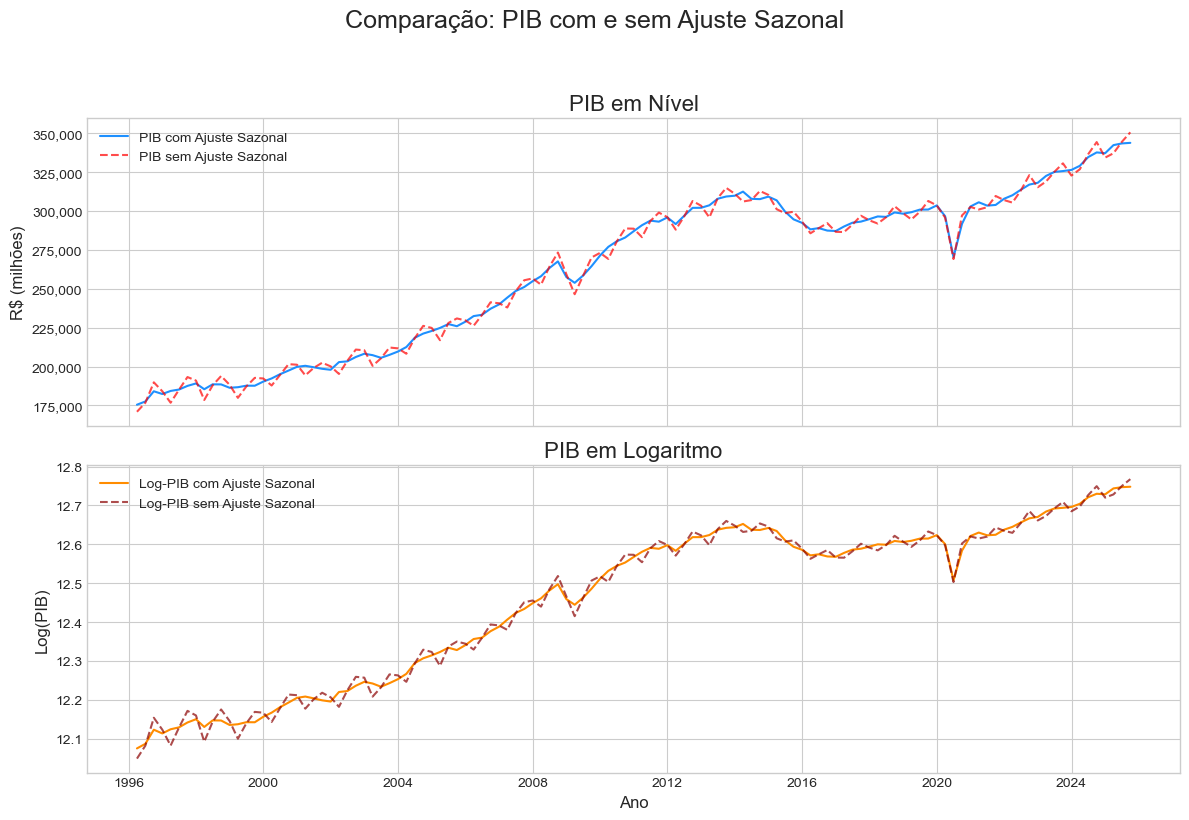

In [15]:
# --- REPROCESSANDO A SÉRIE SEM AJUSTE SAZONAL ---

# O DataFrame DF_PIB_SEM_AJUSTE também foi carregado com a primeira linha como cabeçalho.
# Vamos aplicar a mesma correção.

# 1. Recuperar a primeira linha e renomear colunas
header_row_sem_ajuste = pd.DataFrame([DF_PIB_SEM_AJUSTE.columns], columns=['data_raw', 'pib_sem_ajuste'])
DF_PIB_SEM_AJUSTE.columns = ['data_raw', 'pib_sem_ajuste']

# 2. Concatenar a linha do cabeçalho de volta ao topo
pib_sem_ajuste_corrigido = pd.concat([header_row_sem_ajuste, DF_PIB_SEM_AJUSTE], ignore_index=True)

# 3. Usar a mesma função para converter a data e definir como índice
pib_sem_ajuste_corrigido['data'] = pib_sem_ajuste_corrigido['data_raw'].apply(parse_ibge_quarter)
pib_sem_ajuste_corrigido.dropna(subset=['data'], inplace=True)
pib_sem_ajuste_corrigido.set_index('data', inplace=True)

# 4. Converter para tipo numérico e calcular o log
pib_sem_ajuste_corrigido['pib_sem_ajuste'] = pd.to_numeric(pib_sem_ajuste_corrigido['pib_sem_ajuste'])
pib_sem_ajuste_corrigido['ln_pib_sem_ajuste'] = np.log(pib_sem_ajuste_corrigido['pib_sem_ajuste'])


# --- GRÁFICOS COMPARATIVOS ---

# Juntar os dois DataFrames para facilitar a plotagem
df_comparativo = pib_df_corrigido.join(pib_sem_ajuste_corrigido[['pib_sem_ajuste', 'ln_pib_sem_ajuste']])

# Criar uma figura com dois subplots
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
fig.suptitle('Comparação: PIB com e sem Ajuste Sazonal', fontsize=18, y=1.02)

# --- Gráfico 1: Séries em Nível ---
ax1.plot(df_comparativo.index, df_comparativo['pib'], label='PIB com Ajuste Sazonal', color='dodgerblue')
ax1.plot(df_comparativo.index, df_comparativo['pib_sem_ajuste'], label='PIB sem Ajuste Sazonal', color='red', linestyle='--', alpha=0.7)
ax1.set_title('PIB em Nível')
ax1.set_ylabel('R$ (milhões)')
ax1.legend()
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# --- Gráfico 2: Séries em Log ---
ax2.plot(df_comparativo.index, df_comparativo['ln_pib'], label='Log-PIB com Ajuste Sazonal', color='darkorange')
ax2.plot(df_comparativo.index, df_comparativo['ln_pib_sem_ajuste'], label='Log-PIB sem Ajuste Sazonal', color='darkred', linestyle='--', alpha=0.7)
ax2.set_title('PIB em Logaritmo')
ax2.set_ylabel('Log(PIB)')
ax2.set_xlabel('Ano')
ax2.legend()

# --- Ajustes Finais ---
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Ajusta para o super-título não sobrepor
plt.show()

In [16]:
# --- EXPORTAR DADOS TRATADOS ---

# Definir os nomes dos arquivos de saída
output_path_pkl = 'pib_tratado.pkl'
output_path_csv = 'pib_tratado.csv'

try:
    # Vamos salvar apenas as colunas que realmente interessam para a próxima fase
    colunas_para_salvar = ['pib', 'ln_pib', 'crescimento_pib']
    
    # Opção 1: Salvar em formato Pickle (recomendado)
    pib_df_corrigido[colunas_para_salvar].to_pickle(output_path_pkl)
    
    # Opção 2: Salvar em formato CSV
    pib_df_corrigido[colunas_para_salvar].to_csv(output_path_csv)
    
    print(f"Dados do PIB exportados com sucesso para:")
    print(f"- {output_path_pkl} (Pickle)")
    print(f"- {output_path_csv} (CSV)")

except Exception as e:
    print(f"Ocorreu um erro ao exportar os dados: {e}")

Dados do PIB exportados com sucesso para:
- pib_tratado.pkl (Pickle)
- pib_tratado.csv (CSV)
